In [ ]:
# Imports
from skimage import io, segmentation, color
from skimage.graph import rag_mean_color, cut_threshold
from skimage.segmentation import slic, mark_boundaries
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# Step 1: Upload image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
img = io.imread(img_path)

Saving images (1).jpg to images (1) (1).jpg


In [ ]:
# Step 2: Create superpixels with SLIC
labels = slic(img, n_segments=200, compactness=10, start_label=0)

In [ ]:
# Step 3: Build the RAG (using mean color)
rag = rag_mean_color(img, labels)

In [ ]:
# Step 4: Merge regions using a color similarity threshold
labels_merged = cut_threshold(labels, rag, 35)  # threshold can be tuned

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

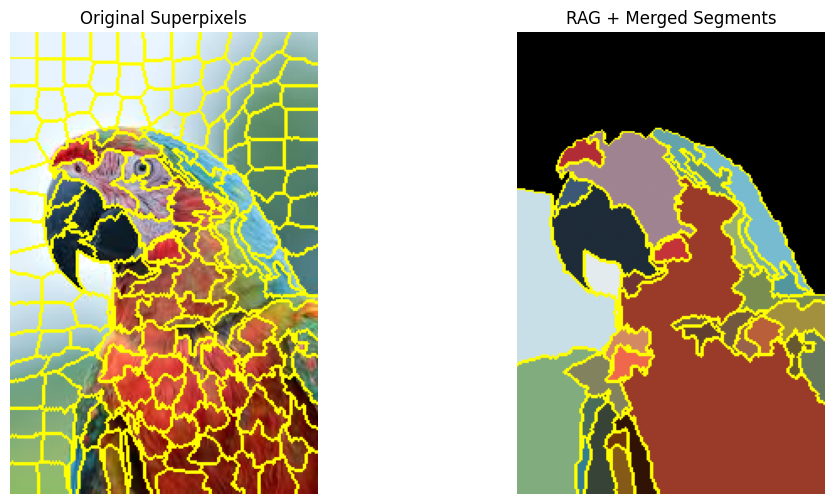

In [ ]:
# Step 5: Visualize
out = color.label2rgb(labels_merged, img, kind='avg')

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(mark_boundaries(img, labels))
plt.title("Original Superpixels")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mark_boundaries(out, labels_merged))
plt.title("RAG + Merged Segments")
plt.axis("off")
